In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px



banque = pd.read_csv("p1_transactions_bancaires.csv")

banque.head()

,transaction_id,date,client_id,banque,categorie,type,montant,solde_apres,ville,canal
0,TXN000001,2024-11-23,CLIENT_0189,BNP Paribas,Transport,Débit,-691.20,2959.77,Lyon,Mobile
1,TXN000002,2024-08-04,CLIENT_0007,La Banque Postale,Alimentation,Débit,-550.50,7333.01,Bordeaux,Mobile
2,TXN000003,2024-08-02,CLIENT_0195,Société Générale,Santé,Débit,-699.09,12974.15,Nantes,Prélèvement
3,TXN000004,2024-05-22,CLIENT_0098,BNP Paribas,Logement,Débit,-1909.92,1084.26,Toulouse,Prélèvement
4,TXN000005,2024-11-05,CLIENT_0097,BNP Paribas,Loisirs,Débit,-1825.68,7811.54,Lille,Mobile


In [6]:
banque.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  3000 non-null   object 
 1   date            3000 non-null   object 
 2   client_id       3000 non-null   object 
 3   banque          3000 non-null   object 
 4   categorie       3000 non-null   object 
 5   type            3000 non-null   object 
 6   montant         3000 non-null   float64
 7   solde_apres     3000 non-null   float64
 8   ville           3000 non-null   object 
 9   canal           3000 non-null   object 
dtypes: float64(2), object(8)
memory usage: 234.5+ KB


In [7]:
banque.describe()


,montant,solde_apres
count,3000.000000,3000.000000
mean,281.266780,7171.266480
std,2151.588621,4560.519816
min,-2499.020000,-498.670000
25%,-1460.392500,3077.820000
50%,-380.975000,7201.800000
75%,1932.490000,11199.687500
max,4994.600000,14986.470000


In [8]:
banque.shape


(3000, 10)

In [12]:
# faire une copie du dataframe pour ne pas modifier l'original
banque_copy = banque.copy()
banque_copy.head(3)

,transaction_id,date,client_id,banque,categorie,type,montant,solde_apres,ville,canal
0,TXN000001,2024-11-23,CLIENT_0189,BNP Paribas,Transport,Débit,-691.20,2959.77,Lyon,Mobile
1,TXN000002,2024-08-04,CLIENT_0007,La Banque Postale,Alimentation,Débit,-550.50,7333.01,Bordeaux,Mobile
2,TXN000003,2024-08-02,CLIENT_0195,Société Générale,Santé,Débit,-699.09,12974.15,Nantes,Prélèvement


# NETTOYAGE ET PREPARATION DES DONNEES

In [ ]:
# Détection des valeurs manquantes
banque_copy.isnull().sum()

In [ ]:
# Convertir la colonne 'date' en type datetime
banque_copy['date'] = pd.to_datetime(banque_copy['date'])


In [18]:
#Creation de la colonne dérivée: Mois de Transaction
banque_copy['mois_transaction'] = banque_copy['date'].dt.month

#Valeur absolue du Montant(Utile pour calculer le panier moyen sans signe)
banque_copy['abs_montant'] = banque_copy['montant'].abs()

banque_copy['negative_balance'] = banque_copy['solde_apres'] < 0

In [19]:
banque_copy.head(3)

,transaction_id,date,client_id,banque,categorie,type,montant,solde_apres,ville,canal,mois_transaction,abs_montant,negative_balance
0,TXN000001,2024-11-23,CLIENT_0189,BNP Paribas,Transport,Débit,-691.20,2959.77,Lyon,Mobile,11,691.20,False
1,TXN000002,2024-08-04,CLIENT_0007,La Banque Postale,Alimentation,Débit,-550.50,7333.01,Bordeaux,Mobile,8,550.50,False
2,TXN000003,2024-08-02,CLIENT_0195,Société Générale,Santé,Débit,-699.09,12974.15,Nantes,Prélèvement,8,699.09,False


ANALYSE DESCRIPTIVE

In [ ]:
#Quelles catégories de dépenses représentent le plus gros volume de transactions ?
# identifier les catégories qui génèrent le plus de transactions et de montants

banque_copy.groupby('categorie').size().sort_values(ascending=False)


In [ ]:
#Quels clients ont le plus souvent un solde négatif (risque de découvert) ?

#banque_copy[banque_copy['negative_balance'] == True].groupby('client_id').size().sort_values(ascending=False).head(10)

# Compter le nombre de découverts par client
decouverts_par_client = banque_copy.groupby("client_id")["negative_balance"].sum()

# Classer les clients par fréquence de découvert
top_10_clients_risque = decouverts_par_client.sort_values(ascending=False).head(10)
print(top_10_clients_risque)

In [33]:
#Quel est le mois avec le plus fort volume de dépenses sur l'année ?
#banque_copy[banque_copy["type"]=="Débit"].groupby(banque_copy["mois_transaction"])["montant"].sum()

# Filtrer uniquement les Débits
debits = banque_copy[banque_copy["type"]=="Débit"]

# Extraire le mois
debits["mois"] = debits["date"].dt.month

# Agréger par mois
depenses_par_mois = debits.groupby("mois")["montant"].sum()

# Identifier le mois avec le plus fort volume
mois_max_depenses = depenses_par_mois.idxmin()  # idxmin car montants sont négatifs
valeur_max = depenses_par_mois.min()

print("Mois avec le plus fort volume de dépenses :", mois_max_depenses, "avec", valeur_max)



Mois avec le plus fort volume de dépenses : 10 avec -214700.38


C:\Users\ARISTIDE FISCHER\AppData\Local\Temp\ipykernel_21268\991102083.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  debits["mois"] = debits["date"].dt.month


In [ ]:
#Quel est le panier moyen par type de transaction (débit vs crédit) ?

panier_moyen = banque_copy.groupby("type")["abs_montant"].mean()
print(panier_moyen)

In [ ]:
#Quels canaux de paiement sont les plus utilisés par les clients ?
canaux_utilises = banque_copy["canal"].value_counts(normalize=True) * 100
print(canaux_utilises)

In [43]:
#Quelle est la répartition des transactions par ville ?
repartition_ville = banque_copy.groupby("ville").size()
print(repartition_ville)

ville
Bordeaux      358
Lille         368
Lyon          387
Marseille     361
Nantes        399
Paris         368
Strasbourg    378
Toulouse      381
dtype: int64


In [60]:
#Détection du découvert

banque_copy["negative_balance"] = banque_copy["solde_apres"] < 0
clients_decouverts = banque_copy.groupby("client_id")["negative_balance"].sum()
clients_decouverts[clients_decouverts > 3]  # clients avec +3 découverts


client_id
CLIENT_0185    4
Name: negative_balance, dtype: int64

In [62]:
#Dépense excessive
seuil = 5000
depenses_excessives = banque_copy[(banque_copy["type"]=="Débit") & (banque_copy["abs_montant"] > seuil)]


In [63]:
#Cohérence débit/crédit

anomalies = banque_copy[(banque_copy["type"]=="Crédit") & (banque_copy["solde_apres"] < 0)]


In [64]:
#Saisonnalité des dépenses

depenses_mensuelles = banque_copy[banque_copy["type"]=="Débit"].groupby(banque_copy["date"].dt.month)["abs_montant"].sum()
moyenne_annuelle = depenses_mensuelles.mean()
pics = depenses_mensuelles[depenses_mensuelles > moyenne_annuelle * 1.3]


In [65]:
#Segmentation clients

solde_moyen = banque_copy.groupby("client_id")["solde_apres"].mean()
freq_decouvert = banque_copy.groupby("client_id")["is_negative_balance"].mean()

clients_fragiles = solde_moyen[solde_moyen < 200]
clients_risque = freq_decouvert[freq_decouvert > 0.1]


In [68]:
banque_copy.head(3)

,transaction_id,date,client_id,banque,categorie,type,montant,solde_apres,ville,canal,mois_transaction,abs_montant,negative_balance,depense_elevée
0,TXN000001,2024-11-23,CLIENT_0189,BNP Paribas,Transport,Débit,-691.20,2959.77,Lyon,Mobile,11,691.20,False,False
1,TXN000002,2024-08-04,CLIENT_0007,La Banque Postale,Alimentation,Débit,-550.50,7333.01,Bordeaux,Mobile,8,550.50,False,False
2,TXN000003,2024-08-02,CLIENT_0195,Société Générale,Santé,Débit,-699.09,12974.15,Nantes,Prélèvement,8,699.09,False,False


VISUALISATION DES DONNEES

In [45]:
#Courbe mensuelle des dépenses (Débits)
#Objectif : montrer l’évolution des dépenses sur 12 mois.


# Calcul des dépenses mensuelles (Débits uniquement)
depenses_mensuelles = banque_copy[banque_copy["type"]=="Débit"].groupby(banque_copy["date"].dt.month)["montant"].sum().reset_index()

# Renommer les colonnes pour plus de clarté
depenses_mensuelles.columns = ["Mois", "Total Dépenses"]

# Création du graphique interactif
fig = px.line(
    depenses_mensuelles,
    x="Mois",
    y="Total Dépenses",
    markers=True,
    title="Évolution des dépenses mensuelles (Débits)",
    line_shape="linear"
)

# Personnalisation
fig.update_traces(line=dict(color="red"))
fig.update_layout(
    xaxis_title="Mois",
    yaxis_title="Total Dépenses (€)",
    template="plotly_white"
)

fig.show()



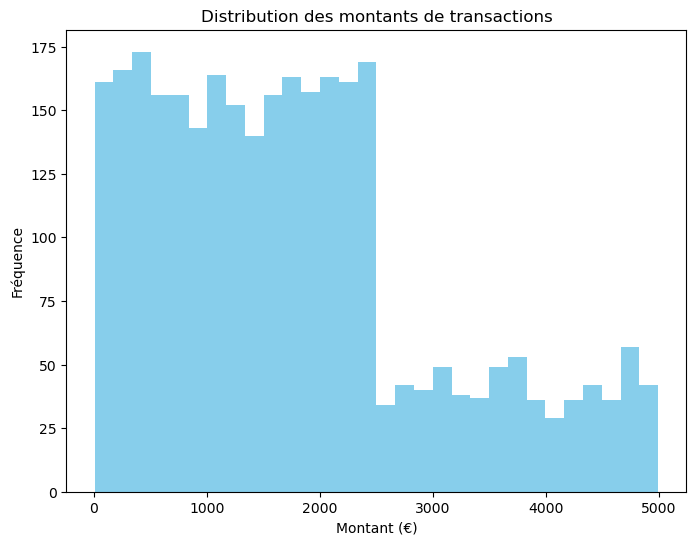

In [49]:
#Histogramme des montants de transactions
#Objectif : analyser la distribution des montants.

banque_copy["abs_montant"].plot(kind="hist", bins=30, figsize=(8,6), color="skyblue")
plt.title("Distribution des montants de transactions")
plt.xlabel("Montant (€)")
plt.ylabel("Fréquence")
plt.show()


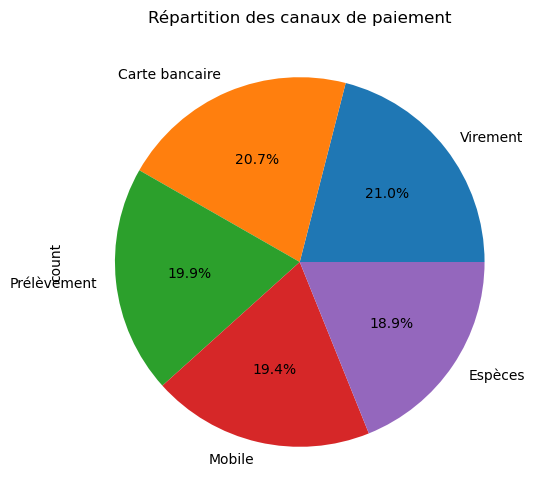

In [53]:
#Camembert des canaux de paiement
#Objectif : visualiser la répartition des canaux.

#banque_copy["canal"].value_counts().plot(kind="pie", autopct="%1.1f%%", figsize=(8,6))

banque_copy["canal"].value_counts().plot.pie(
    autopct="%1.1f%%", 
    figsize=(8,6), 
    title="Répartition des canaux de paiement"
)
plt.show()


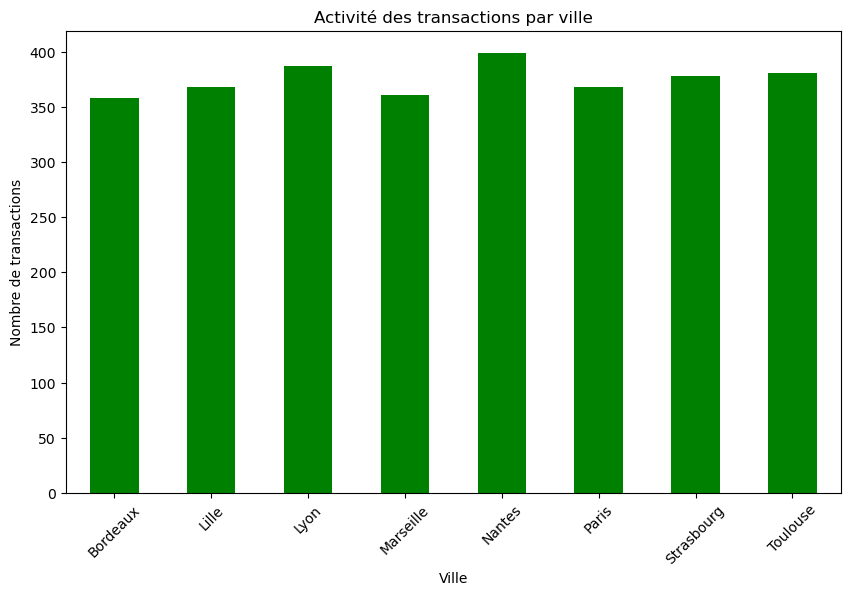

In [56]:
#Bar chart des transactions par ville
#Objectif : comparer l’activité par ville.

banque_copy.groupby("ville")["transaction_id"].count().plot(kind="bar", figsize=(10,6), color="green")
plt.title("Activité des transactions par ville")
plt.xlabel("Ville")
plt.ylabel("Nombre de transactions")
plt.xticks(rotation=45)
plt.show()
